<a href="https://www.kaggle.com/code/abdullahzulfiqar2005/zameen-com-processed-data?scriptVersionId=304783688" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = '/kaggle/input/datasets/huzzefakhan/zameencom-property-data-pakistan/Property.csv'

# Original csv file is separated by ";" 
df = pd.read_csv(path, sep=';')

df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN


We imported libraries and loaded our csv file which was separated by ";" in our notebook. Used head() to see data is loaded successfully. 

In [2]:
# 1. Print the mathematical stats for the numerical columns (like price and baths)
print("--- Basic Statistics ---")
display(df.describe())

# 2. Count exactly how many missing (blank) values are in every single column
print("\n--- Missing Values Count ---")
display(df.isnull().sum())

--- Basic Statistics ---


,property_id,location_id,price,latitude,longitude,baths,bedrooms
count,1.913930e+05,191393.000000,1.913930e+05,191393.000000,191393.000000,191393.000000,191393.000000
mean,1.573170e+07,4224.580350,1.644655e+07,30.104593,71.572992,2.865956,3.171516
std,2.215249e+06,3719.125201,3.416412e+07,3.645941,3.080463,2.435332,1.952403
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000
25%,1.511867e+07,1057.000000,8.000000e+04,24.972287,67.152597,0.000000,2.000000
50%,1.676385e+07,3233.000000,7.300000e+06,31.463563,73.077743,3.000000,3.000000
75%,1.715282e+07,7182.000000,1.800000e+07,33.550869,74.228218,4.000000,4.000000
max,1.769386e+07,14246.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000



--- Missing Values Count ---


property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           47379
agent            47380
dtype: int64

After loading the raw dataset we used describe() to understand mathematical distribution (mean, min, max) of our features. The isnull.sum() function highlighted exactly which column contains missing data. This initial statistical analysis dictates which features require pre-processing before we train our actual model.

In [3]:
def clean_area(text):
    try:
        text = str(text).lower().replace(',', '')
        
        if 'kanal' in text:
            num = float(text.replace('kanal', '').strip())
            return num * 20  # 1 Kanal = 20 Marlas
        elif 'marla' in text:
            num = float(text.replace('marla', '').strip())
            return num
        else:
            return None
            
    except ValueError:
        return None

df['area_in_marlas'] = df['area'].apply(clean_area)

display(df[['area', 'area_in_marlas']].head(10))

,area,area_in_marlas
0,6 Kanal,120.0
1,1 Kanal,20.0
2,9 Marla,9.0
3,1 Kanal,20.0
4,11 Marla,11.0
5,1 Kanal,20.0
6,8 Marla,8.0
7,1 Kanal,20.0
8,1 Kanal,20.0
9,1.6 Kanal,32.0


The original area column was in string format containing mixed text units ( "5 Marla", "1.6 Kanal"). Since we can't visualize this format, we pre-process it first, by making a new column "area_in_marlas", by stripping the text and mathematically converting Kanals to Marlas (1 Kanal = 20 Marlas).

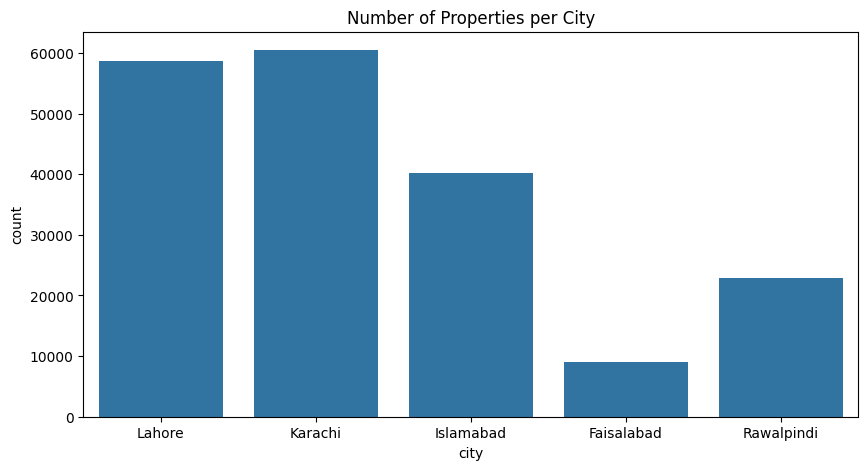

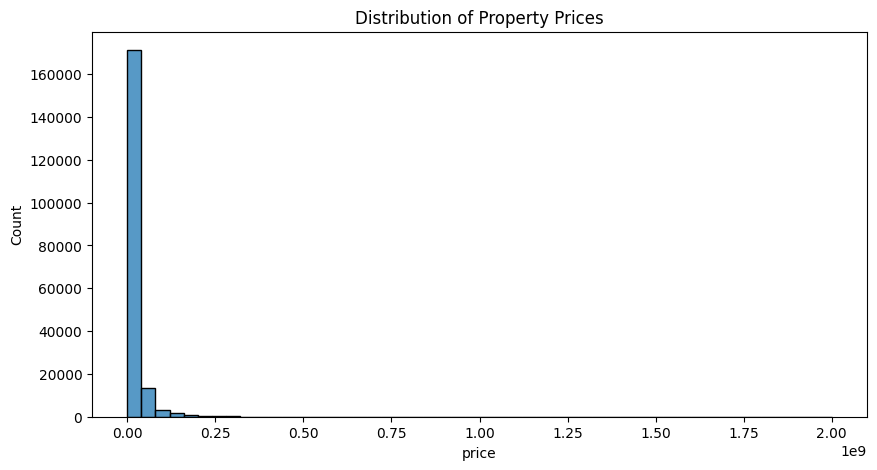

In [4]:
# Plot 1: A bar chart showing the number of properties in each city
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='city')
plt.title('Number of Properties per City')
plt.show()

# Plot 2: A histogram showing the distribution of prices
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title('Distribution of Property Prices')
plt.show()

Through visual analysis, we can understand the distribution of different features.
City Distribution: This bar chart shows how data is distributed across major cities, showing which regions have highest density of listings in our dataset.
Price Distribution: This histogram is heavily right-skewed. 

In [5]:
# Drop columns that are just noise
columns_to_drop = ['property_id', 'location_id', 'page_url', 'agency', 'agent', 'date_added', 'area']
df = df.drop(columns=columns_to_drop)
print('Columns dropped successfully')

Columns dropped successfully


We dropped property_id, location_id, page_url, date_added, agency, and agent because they are irrelevant features. These contain administrative metadata that have no logical and mathematical relationship to physical market value of a house. Keeping them would be a noise to regression model.

In [6]:
# Save the clean data
df.to_csv('cleaned_zameen_data.csv', index=False)
print("Clean dataset saved successfully!")

Clean dataset saved successfully!


We saved our pre-processed data to csv to save time for future phases of project. In next phase we will load this csv file.